<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/MonteCarlo_OffPolicy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MonteCarlo Off-Policy

*Description*: En este notebook se desarrolla la implementación del método de **Monte Carlo Off-Policy (todas las visitas y muestreo por importancia ponderado)**, y se emplea sobre los entornos Taxi-v3 y Frozen Lake de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/20


Empezamos instalando e importando las librerías necesarias. También definimos los dispositivos donde se ejecutará el notebook y la semilla que vamos a usar para asegurar reproducibilidad.

In [1]:
%%capture
!pip install 'gym[box2d]==0.20.0'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc
import os

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


gc.collect()              # Ejecuta el recolector de basura de Python
if torch.cuda.is_available():
    torch.cuda.empty_cache()   # Limpia la caché de la GPU


SEED = 42

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

Usando dispositivo: cpu


## Agente

En este apartado construimos un agente basado en **Monte Carlo Off-Policy (every-visit con muestreo por importancia ponderado)** para los entornos *Taxi-v3* y *FrozenLake* de Gymnasium. A diferencia del enfoque *On-Policy*, aquí separamos claramente:

- La política que **genera los episodios**.
- La política que **queremos optimizar**.

Esta distinción permite explorar de forma controlada mientras estimamos los valores asociados a una política distinta. Las políticas empleadas son:

- **Política de comportamiento ($b$)**: Utilizamos una política $\epsilon$-greedy derivada de una política $\epsilon$-soft. Esto garantiza que todas las acciones tengan probabilidad estrictamente positiva y que se cumpla la condición necesaria para aplicar muestreo de importancia. Además, podemos regular fácilmente la exploración mediante el parámetro $\epsilon$. Si fijamos $\epsilon = 1$, la política se vuelve completamente uniforme. En realidad podríamos haber usado cualquier política soft, pero optamos por esta, pues nos permite más flexibilidad a la hora de experimentar.

- **Política objetivo ($\pi$)**  
La política objetivo es estrictamente **greedy** respecto a los valores actuales de $Q$.  
En cada estado se selecciona:

$$
\pi(s) = \arg\max_a Q(s,a)
$$

Es decir, es determinista y siempre escoge la acción con mayor valor estimado.


Una vez finalizado cada episodio, procesamos la trayectoria en orden inverso (desde el último paso hasta el primero). Para cada aparición del par $(S_t, A_t)$ aplicamos la actualización mediante **muestreo de importancia ponderado**.

La regla incremental es:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) +
\frac{W}{C(S_t, A_t)} \bigl(G_t - Q(S_t, A_t)\bigr)
$$

donde:

- $G_t$ es el retorno acumulado desde el instante $t$ hasta el final.
- $C(S_t, A_t)$ acumula los pesos asociados a ese par.
- $W$ es el peso de importancia acumulado.

En cada paso, la $C$ se actualiza siguiendo la expresión:

$$
C(S_t, A_t) \leftarrow C(S_t, A_t) + W
$$

Este término actúa como normalizador, permitiendo una estimación incremental estable. Por otro lado, el peso $W$ comienza en $W=1$ y se actualiza como:

$$
W \leftarrow W \cdot \frac{1}{b(A_t \mid S_t)}
$$

Sin embargo, si en algún punto la acción ejecutada no es la que elegiría la política greedy, se detiene la propagación hacia atrás (equivalente a que el peso pase a ser cero). Esto ocurre porque la política objetivo asigna probabilidad cero a cualquier acción no óptima.

In [4]:


class MonteCarloOffPolicyAgent:

    def __init__(self, env: gym.Env, epsilon: float, use_decay: bool, gamma: float):
        self.env = env
        self.eps = epsilon
        self.use_decay = use_decay
        self.gamma = gamma

        self.n_actions = env.action_space.n
        self.n_states = env.observation_space.n

        # Inicialización de tablas: Q (valores), C (pesos acumulados) y retornos
        self.q_table = np.zeros((self.n_states, self.n_actions))
        self.c_table = np.zeros((self.n_states, self.n_actions))
        self.history_returns = {}

    def get_q_values(self):
        return self.q_table

    def log_return(self, state, action, g_value):
        key = (state, action)
        if key not in self.history_returns:
            self.history_returns[key] = []
        self.history_returns[key].append(g_value)

    def get_return(self, state, action):
        return self.history_returns[(state, action)]

    # --- Gestión de Políticas ---

    # Política uniforme
    def get_action_uniform(self, state):
        return np.random.choice(np.arange(self.n_actions))

    def get_uniform_policy(self, state):
        return np.ones(self.n_actions) / self.n_actions

    # Política epsilon-soft. Se usa para el entrenamiento
    def random_epsilon_greedy_policy(self, state):
        pi_A = np.ones(self.n_actions, dtype=float) * self.eps / self.n_actions
        best_action = np.argmax(self.q_table[state])
        pi_A[best_action] += (1.0 - self.eps)
        return pi_A

    # Política epsilon-greedy a partir de una epsilon-soft
    def epsilon_greedy_policy(self, state):
        pi_A = self.random_epsilon_greedy_policy(state)
        return np.random.choice(np.arange(self.n_actions), p=pi_A)

    # Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
    def pi_star_from_Q(self, env):
        done = False
        pi_star = np.zeros([env.observation_space.n, env.action_space.n])
        state, info = env.reset() # start in top-left, = 0
        actions = ""
        while not done:
            action = np.argmax(self.q_table[state, :])
            actions += f"{action}, "
            pi_star[state,action] = action
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        return pi_star, actions


    def update_knowledge(self, episode_data):
        """
        Actualiza Q y C usando la trayectoria del episodio (retrocediendo en el tiempo).
        Implementa Weighted Importance Sampling.
        """
        g_return = 0.0
        weight = 1.0

        # Iterar el episodio desde el final hacia el principio
        for s, a, r in reversed(episode_data):
            g_return = r + self.gamma * g_return

            # Actualización del acumulador de pesos y la función de valor
            self.c_table[s, a] += weight
            self.q_table[s, a] += (weight / self.c_table[s, a]) * (g_return - self.q_table[s, a])

            # Si la acción tomada no es la que dictaría la política objetivo,
            # el peso de la importancia para el resto de la cadena sería 0.
            if a != np.argmax(self.q_table[s]):
                break

            # Actualizar el peso: W = W * (1 / b(a|s))
            weight *= (1.0 / self.random_epsilon_greedy_policy(s)[a])

        return g_return

## Esquema de aprendizaje

La siguiente función implementa el esquema de aprendizaje basándose en el disponile en el notebook disponible en el github del profesor, cambiando y añadiendo lo necesario para que estemos ante la implementación correcta de Monte Carlo. Se observa que es un esquema igual al encontrado en Monte Carlo On Policy, simplemente cambiando las expresiones de actualización de los valores.

In [6]:
def on_policy_all_visit(agente, num_episodes=5000):

    # Número de visitas. Vamoa a realizar la versión incremental.
    #n_visits = np.zeros([env.observation_space.n, env.action_space.n])

    # Para mostrar la evolución en el terminal y algún dato que mostrar
    stats = 0.0
    list_stats = []
    step_display = num_episodes / 10

    longitudes = []

    for t in tqdm(range(num_episodes)):
        state, info = agente.env.reset(seed=SEED)
        done = False
        episode = []
        result_sum = 0.0  # Retorno
        while not done:
            if agente.use_decay:
                agente.eps = min(agente.eps, 1000.0/(t+1))

            action = agente.epsilon_greedy_policy(state)
            new_state, reward, terminated, truncated, info = agente.env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            result_sum += reward
            state = new_state

        g_value = agente.update_knowledge(episode)

        # Guardamos datos sobre la evolución. Promedio de recompensas
        stats += result_sum
        longitudes.append(len(episode))
        list_stats.append(stats/(t+1))

        # Para mostrar la evolución.  Comentar si no se quiere mostrar
        if t % step_display == 0 and t != 0:
            print(f"success: {stats/t}, epsilon: {agente.eps}")

    return longitudes, list_stats

## Funciones auxiliares

Ahora vamos a definir una serie de funciones auxiliares que nos van a servir para mostrar resultados y realizar el análisis.

La primera función que definimos la usaremos una vez entrenado el agente, de forma que podamos evaluar el aprendizaje llevado a cabo.

In [7]:
def capture_optimal_behavior(agente, limit_steps=200):
    """
    Graba un episodio completo siguiendo la política óptima del agente
    y devuelve las métricas de rendimiento junto con los frames de video.
    """
    visual_frames = []
    current_state, _ = agente.env.reset(seed=SEED)

    accumulated_reward = 0.0
    steps_count = 0
    is_finished = False

    while not is_finished and steps_count < limit_steps:
        # 1. Capturar el estado visual actual
        img_frame = agente.env.render()
        visual_frames.append(img_frame)

        # 2. Decidir acción basada en la política objetivo (greedy)
        chosen_action = np.argmax(agente.get_q_values()[current_state, :])

        # 3. Ejecutar transición en el entorno
        next_s, reward, terminated, truncated, _ = agente.env.step(chosen_action)

        # 4. Actualizar contadores y estado
        accumulated_reward += reward
        current_state = next_s
        steps_count += 1
        is_finished = terminated or truncated

    # Capturar el último frame tras el fin del episodio
    visual_frames.append(agente.env.render())
    agente.env.close()

    return accumulated_reward, steps_count, visual_frames

Las siguiente funciones mostrarán las gráficas de aprendizaje y longitud de los episodios una vez realizado el aprendizaje de los agentes.

La longitud del episodio es un medidor de rendimiento interesante porque no solo indica si el agente alcanza la meta, sino también **cómo de eficiente es la política aprendida**. En entornos donde existe una ruta óptima, la convergencia hacia un número estable y bajo de pasos suele reflejar que el agente ha aprendido un comportamiento estructurado y cercano al óptimo.

Además, esta métrica permite interpretar mejor los resultados: episodios muy cortos pueden indicar caídas tempranas en estados terminales negativos, mientras que episodios largos pueden reflejar exploración excesiva o movimientos erráticos. Por ello, la longitud del episodio complementa a la recompensa promedio y ayuda a entender no solo si el agente aprende, sino **cómo está aprendiendo**.

In [8]:
def draw_multiple_learning_curves(results_dict):
    """
    Representa varias curvas de entrenamiento en el mismo gráfico.

    results_dict:
        Diccionario donde:
        clave -> nombre experimento/agente
        valor -> lista con historial de métricas
    """

    first_key = next(iter(results_dict))
    x_axis = np.arange(len(results_dict[first_key]))

    fig, ax = plt.subplots(figsize=(10, 4))

    for experiment_name, history in results_dict.items():
        ax.plot(x_axis, history, label=experiment_name)

    ax.set_title("Comparativa de rendimiento")
    ax.set_xlabel("Número de episodio")
    ax.set_ylabel("Valor medio")
    ax.legend()

    ax.grid()
    plt.show()


def compute_running_mean(series, window):
    """
    Calcula un suavizado tipo media deslizante sobre una serie temporal.
    """
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")


def draw_episode_length_trend(length_history):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    # Señal original (transparente)
    ax.plot(length_history, alpha=0.25, color="forestgreen")

    # Tendencia suavizada
    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    ax.set_title("Evolución del tamaño de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange", "lightblue"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        # Señal original
        ax.plot(values, alpha=0.2, color=color)

        # Tendencia suavizada
        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    ax.set_title("Comparativa de longitudes de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

Las siguientes funciones servirán para visualizar los resultados con imágenes y gifs del comportamiento del agente.

In [9]:
import seaborn as sns
import imageio
import base64
from IPython.display import HTML
import matplotlib.pyplot as plt

def get_taxi_qtable_directions(qtable, env):
    """
    Extrae la matriz de valores Q máximos y los símbolos de las mejores acciones
    para una configuración específica del pasajero y destino en Taxi-v3.
    """
    state, _ = env.reset(seed=SEED)
    _, _, pass_idx, dest_idx = env.unwrapped.decode(state)
    q_max_grid = np.zeros((5, 5))
    directions_grid = np.empty((5, 5), dtype=object)

    # Mapeo de acciones para Taxi-v3
    # 0: Sur, 1: Norte, 2: Este, 3: Oeste, 4: Recoger (P), 5: Dejar (D)
    action_symbols = {0: '↓', 1: '↑', 2: '→', 3: '←', 4: 'P', 5: 'D'}

    for row in range(5):
        for col in range(5):
            # Decodificamos el estado para fijar al pasajero y el destino
            state = env.unwrapped.encode(row, col, pass_idx, dest_idx)

            best_action = int(np.argmax(qtable[state]))
            max_q_value = np.max(qtable[state])

            q_max_grid[row, col] = max_q_value
            directions_grid[row, col] = action_symbols[best_action]

    return q_max_grid, directions_grid


def plot_taxi_q_values_map(qtable, env):
    '''
    Plotea el entorno real en un estado concreto junto con un mapa de calor
    (Heatmap) de la política aprendida y los valores Q máximos.
    '''

    # Obtenemos las matrices de valores y direcciones
    q_max_grid, directions_grid = get_taxi_qtable_directions(qtable, env)

    # Configuramos el gráfico
    plt.figure(figsize=(7, 6))

    ax = sns.heatmap(
        q_max_grid,
        annot=directions_grid,
        fmt="",
        cmap=sns.color_palette("Blues", as_cmap=True), # Mantenemos la paleta "Blues"
        linewidths=1.5,
        linecolor="black", # Líneas negras para que resalte la cuadrícula (como en Frozen Lake)
        xticklabels=[],
        yticklabels=[],
        cbar_kws={'label': 'Max Q-Value estimado'},
        annot_kws={"fontsize": 18, "weight": "bold", "color": "black"}, # Letras y flechas muy claras
    )
    ax.set_title("Learned Q-values\nArrows and letters (P/D) represent best action", fontsize=14)

    # Borde negro para el heatmap
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()



def create_gif_from_frames(frame_list, output_path="frozenlake_agent.gif"):
    """
    Genera un GIF animado a partir de una lista de imágenes.

    Parámetros:
      - frame_list (list): Lista de frames capturados del entorno.
      - output_path (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Ruta del GIF creado.
    """
    with imageio.get_writer(output_path, mode="I") as gif_writer:
        for frame in frame_list:
            gif_writer.append_data(frame)
    return output_path


def show_gif_in_notebook(gif_file_path):
    """
    Inserta un GIF en una celda de Jupyter Notebook o Colab.

    Parámetros:
      - gif_file_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML para mostrar el GIF.
    """
    with open(gif_file_path, "rb") as f:
        gif_bytes = f.read()

    b64_str = base64.b64encode(gif_bytes).decode("utf-8")
    return HTML(f'<img src="data:image/gif;base64,{b64_str}" />')

## Entorno Taxi-v3

A continuación, creamos el entorno "Taxi-v3" de Gymnasium con el que trabajaremos.

`Taxi-v3` es un entorno estructurado de 500 estados utilizado para evaluar la escalabilidad de algoritmos tabulares.  

**Características del Entorno:**
* **Estados (500):** Combina 25 posiciones del taxi (cuadrícula 5x5), 5 posiciones posibles del pasajero (4 ubicaciones + dentro del taxi) y 4 destinos posibles.
* **Acciones (6):** Moverse al Sur, Norte, Este, Oeste, Recoger pasajero (Pickup) y Dejar pasajero (Dropoff).
* **Recompensas:**
  * **-1** por cada paso ejecutado (presiona al agente a encontrar la ruta más rápida).
  * **+20** por dejar al pasajero en su destino correctamente.
  * **-10** por ejecutar erróneamente *Pickup* o *Dropoff* en ubicaciones no válidas.

In [10]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

Ahora creamos los diferentes agentes que usaremos. Con el objetivo de analizar el impacto del nivel inicial de exploración y del uso de mecanismos de decaimiento en la probabilidad de exploración, se han definido seis agentes basados en el algoritmo Monte Carlo Off-Policy, todos ellos evaluados en el entorno Taxi-v3.

Se han considerado tres valores iniciales del parámetro ε:

- **$\epsilon$ = 0.3** → exploración moderada  
- **$\epsilon$= 0.7** → exploración elevada  
- **$\epsilon$ = 1.0** → exploración completamente uniforme  

Estos valores permiten cubrir un espectro amplio de comportamientos exploratorios, desde una política relativamente cercana a la explotación hasta una política puramente aleatoria. Dado que la política que explora el entorno no es la misma que la política objetivo que se busca optimizar, es posible permitir una exploración más intensa (valores de $\epsilon$) que en el caso on policy sin comprometer tanto la calidad de la política final.

Para cada valor de $\epsilon$ se han definido dos configuraciones adicionales, uno con epsilon decay y otro sin decay. Con decay, la probabilidad de exploración disminuye progresivamente según el esquema  

$$
\epsilon_t = \min\left(\epsilon_0, \frac{1000}{t+1}\right)
$$

lo que favorece una transición gradual desde exploración hacia explotación.

En todos los casos se fija el factor de descuento en **$\gamma$ = 0.99**, con el objetivo de mantener constante la importancia otorgada a recompensas futuras y aislar exclusivamente el efecto del nivel de exploración y su evolución temporal.

Este diseño permite estudiar:

- La influencia del nivel inicial de exploración en la velocidad de aprendizaje.
- El efecto del decaimiento en la convergencia de la política objetivo.
- La posible interacción entre exploración intensa inicial y transición progresiva hacia explotación.


In [11]:
agent_03_decay = MonteCarloOffPolicyAgent(env, epsilon=0.3, use_decay=True, gamma=0.99)
agent_03_nodecay = MonteCarloOffPolicyAgent(env, epsilon=0.3, use_decay=False, gamma=0.99)
agent_07_decay = MonteCarloOffPolicyAgent(env, epsilon=0.7, use_decay=True, gamma=0.99)
agent_07_nodecay = MonteCarloOffPolicyAgent(env, epsilon=0.7, use_decay=False, gamma=0.99)
agent_1_decay = MonteCarloOffPolicyAgent(env, epsilon=1.0, use_decay=True, gamma=0.99)
agent_1_nodecay = MonteCarloOffPolicyAgent(env, epsilon=1.0, use_decay=False, gamma=0.99)


In [12]:
n_episodes = 10000

list_len, list_stats = on_policy_all_visit(agent_03_decay, n_episodes)

 11%|█         | 1116/10000 [00:07<00:13, 656.98it/s]

success: -219.163, epsilon: 0.3


 21%|██        | 2079/10000 [00:08<00:12, 640.07it/s]

success: -117.221, epsilon: 0.3


 31%|███       | 3118/10000 [00:10<00:10, 664.17it/s]

...

 81%|████████  | 8061/10000 [00:18<00:04, 481.85it/s]

success: -34.283625, epsilon: 0.1249843769528809


 91%|█████████ | 9093/10000 [00:19<00:01, 719.39it/s]

success: -30.407333333333334, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [00:21<00:00, 473.95it/s]


In [13]:
list_len2, list_stats2 = on_policy_all_visit(agent_03_nodecay, n_episodes)

 11%|█         | 1104/10000 [00:03<00:14, 597.07it/s]

success: -100.683, epsilon: 0.3


 21%|██        | 2078/10000 [00:06<00:19, 405.30it/s]

success: -58.1875, epsilon: 0.3


 31%|███       | 3119/10000 [00:08<00:10, 667.40it/s]

...

 81%|████████  | 8124/10000 [00:16<00:02, 654.99it/s]

success: -25.651125, epsilon: 0.3


 91%|█████████ | 9093/10000 [00:17<00:01, 472.19it/s]

success: -24.39511111111111, epsilon: 0.3


100%|██████████| 10000/10000 [00:19<00:00, 502.34it/s]


In [14]:
list_len3, list_stats3 = on_policy_all_visit(agent_07_decay, n_episodes)

 10%|█         | 1016/10000 [00:13<02:07, 70.54it/s]

success: -577.142, epsilon: 0.7


 20%|██        | 2040/10000 [00:21<00:35, 224.56it/s]

success: -449.467, epsilon: 0.49975012493753124


 30%|███       | 3043/10000 [00:25<00:27, 255.79it/s]

...

 81%|████████  | 8104/10000 [00:32<00:02, 754.12it/s]

success: -125.1715, epsilon: 0.1249843769528809


 91%|█████████▏| 9132/10000 [00:34<00:01, 797.21it/s]

success: -111.13733333333333, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [00:35<00:00, 282.20it/s]


In [15]:
list_len4, list_stats4 = on_policy_all_visit(agent_07_nodecay, n_episodes)

 10%|█         | 1020/10000 [00:14<01:41, 88.78it/s]

success: -558.839, epsilon: 0.7


 20%|██        | 2010/10000 [00:24<01:40, 79.62it/s]

success: -491.9315, epsilon: 0.7


 30%|███       | 3030/10000 [00:32<00:48, 144.95it/s]

...

 80%|████████  | 8010/10000 [01:00<00:14, 140.11it/s]

success: -287.905375, epsilon: 0.7


 90%|█████████ | 9033/10000 [01:07<00:05, 174.01it/s]

success: -279.82744444444444, epsilon: 0.7


100%|██████████| 10000/10000 [01:12<00:00, 138.70it/s]


In [16]:
list_len5, list_stats5 = on_policy_all_visit(agent_1_decay, n_episodes)

 10%|█         | 1005/10000 [00:16<03:04, 48.67it/s]

success: -776.63, epsilon: 0.999000999000999


 20%|██        | 2013/10000 [00:31<01:50, 72.08it/s]

success: -697.961, epsilon: 0.49975012493753124


 31%|███       | 3080/10000 [00:36<00:12, 547.08it/s]

...

 81%|████████  | 8091/10000 [00:45<00:02, 668.79it/s]

success: -197.4925, epsilon: 0.1249843769528809


 91%|█████████▏| 9128/10000 [00:46<00:01, 794.77it/s]

success: -175.40755555555555, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [00:48<00:00, 208.26it/s]


In [17]:
list_len6, list_stats6 = on_policy_all_visit(agent_1_nodecay, n_episodes)

 10%|█         | 1008/10000 [00:15<02:46, 54.11it/s]

success: -772.649, epsilon: 1.0


 20%|██        | 2009/10000 [00:30<01:47, 74.00it/s]

success: -774.791, epsilon: 1.0


 30%|███       | 3012/10000 [00:45<01:29, 78.20it/s]

...

 80%|████████  | 8013/10000 [01:56<00:25, 79.22it/s]

success: -775.647375, epsilon: 1.0


 90%|█████████ | 9015/10000 [02:10<00:13, 75.49it/s]

success: -775.522, epsilon: 1.0


100%|██████████| 10000/10000 [02:24<00:00, 69.24it/s]


## Resultados para Taxi-v3

Guardamos los resultados obtenidos en diccionarios para pasárselos a las funciones auxiliares definidas anteriormente para plotear los resultados.

In [18]:
dict_stats = {'eps=0.3, decay=True': list_stats, 'eps=0.3, decay=False': list_stats2, 'eps=0.7, decay=True': list_stats3, 'eps=0.7, decay=False': list_stats4, 'eps=1.0, decay=True': list_stats5, 'eps=1.0, decay=False': list_stats6}
dict_len = {'eps=0.3, decay=True': list_len, 'eps=0.3, decay=False': list_len2, 'eps=0.7, decay=True': list_len3, 'eps=0.7, decay=False': list_len4, 'eps=1.0, decay=True': list_len5, 'eps=1.0, decay=False': list_len6}

Exportamos estos datos para poder hacer gráficas conjuntamente con los otros algoritmos.

In [33]:
np.savez('monte_carlo_off_results.npz', dict_stats=dict_stats, dict_len=dict_len)
print("Resultados guardados en 'monte_carlo_off_results.npz'")

Resultados guardados en 'monte_carlo_off_results.npz'


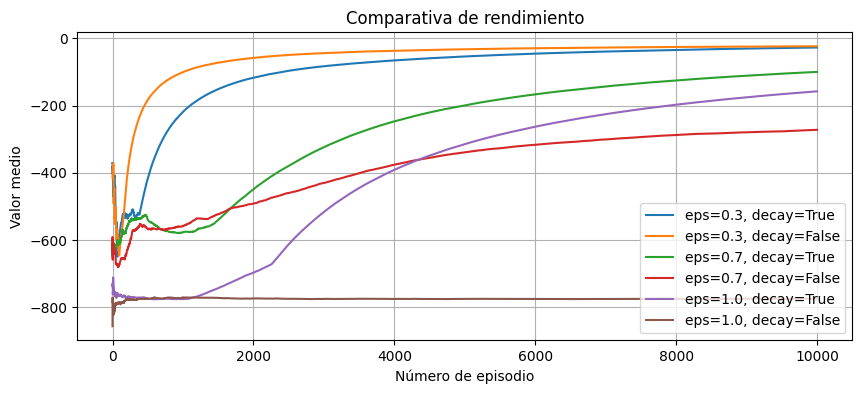

In [19]:
draw_multiple_learning_curves(dict_stats)

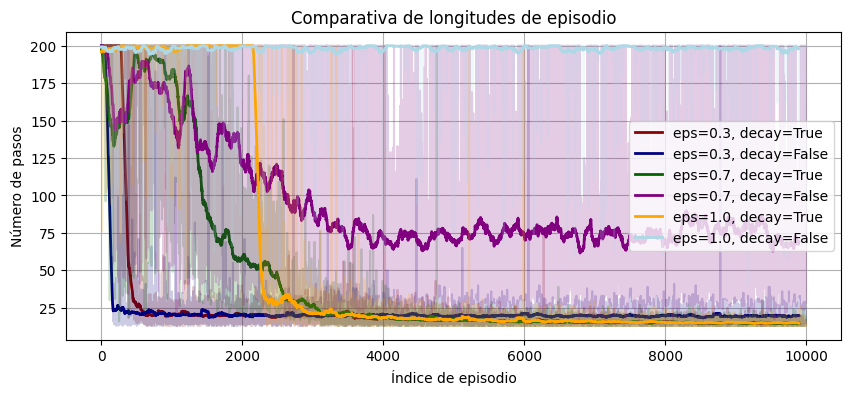

In [20]:
draw_episode_length_comparison(dict_len)

En las figuras se muestran la evolución del reward medio y las longitudes de los episodios en el entorno Taxi-v3 utilizando el algoritmo Monte Carlo Off-Policy. Es importante recordar que la métrica representada corresponde al rendimiento de la **política de comportamiento** \( b \), es decir, la $\epsilon$-greedy empleada para generar los episodios, y no directamente al de la política objetivo greedy que se está optimizando mediante importance sampling. Sin embargo, esta política también se ve influenciada por las actualizaciones de los valores de Q, y una mejora en la longitud de episiodios y en la recompensa muestra una mejora de los valores de Q.

En primer lugar, se observa que los valores intermedios de $\epsilon$ (especialmente $\epsilon$ = 0.3) producen la mejora más rápida y estable del reward medio, tanto con *decay* como sin él. En estos casos, la política de comportamiento logra un equilibrio razonable entre exploración y explotación, permitiendo que la mejora en los valores Q se traduzca progresivamente en un mejor rendimiento observable. La diferencia entre usar *decay* o no es relativamente pequeña en este rango, lo que sugiere que incluso una exploración constante moderada no impide que la política de comportamiento refleje la mejora en la estimación de Q.

Para $\epsilon$ = 0.7 el aprendizaje es más lento y el reward medio permanece considerablemente más negativo durante gran parte del entrenamiento. Esto se debe a que la política de comportamiento introduce un nivel elevado de exploración, lo que penaliza el rendimiento observable aunque la política objetivo pueda estar mejorando internamente. Aun así, se aprecia una tendencia ascendente, lo que indica que la mejora en Q sí acaba influyendo en la acción greedy seleccionada con probabilidad $1-\epsilon + \frac{\epsilon}{n}$

El caso extremo $\epsilon$ = 1.0 resulta especialmente ilustrativo. Sin *decay*, la política de comportamiento es completamente aleatoria durante todo el entrenamiento, por lo que el reward medio permanece prácticamente constante y muy negativo. Sin embargo, esto no implica que la función Q no esté cambiando: simplemente, la política ejecutada no explota en ningún momento la información aprendida. Con *decay*, en cambio, el reward comienza siendo muy bajo pero mejora progresivamente conforme $\epsilon$ disminuye, permitiendo que la política de comportamiento se acerque gradualmente a la política greedy y haga visible la mejora en los valores Q.

En conjunto, los resultados muestran que, aunque la gráfica no representa directamente el rendimiento de la política objetivo, sí refleja indirectamente la mejora de Q cuando $\epsilon$ permite suficiente explotación. Sin embargo, para valores altos y constantes de $\epsilon$, la métrica puede subestimar significativamente el aprendizaje real del agente, ya que evalúa principalmente el comportamiento exploratorio y no la política greedy que se está optimizando.

## Visualización de la política en Taxi-v3

El entorno Taxi-v3 define el estado como una tupla de cuatro componentes:

\[
(row, col, passenger\_idx, destination\_idx)
\]

Esto implica que el espacio de estados es de dimensión 4, por lo que no es posible representar directamente la política completa en un mapa bidimensional.

Para poder visualizar el comportamiento aprendido por el agente, se fija la posición del pasajero y el destino, representando únicamente la política asociada a esa sección concreta del espacio de estados. De esta forma, se construye un mapa 5×5 que muestra la acción greedy seleccionada por el agente para cada posición del taxi bajo esas condiciones fijas.

Es importante destacar que esta representación no muestra la política global del agente, sino una proyección bidimensional condicionada a un estado específico del pasajero y del destino.

En particular, cuando el pasajero aún no ha sido recogido, la política visualizada refleja el comportamiento del agente orientado a desplazarse hacia la posición del pasajero. Una vez el pasajero es recogido, el estado cambia (el índice del pasajero pasa a indicar que está dentro del taxi), y por tanto la política relevante pertenece a otra sección distinta del espacio de estados, que no está incluida en esta visualización.

Por tanto, las tablas presentadas deben interpretarse como cortes del espacio de estados que permiten analizar de forma estructurada el comportamiento aprendido en cada fase de la tarea (búsqueda del pasajero y transporte hacia el destino).

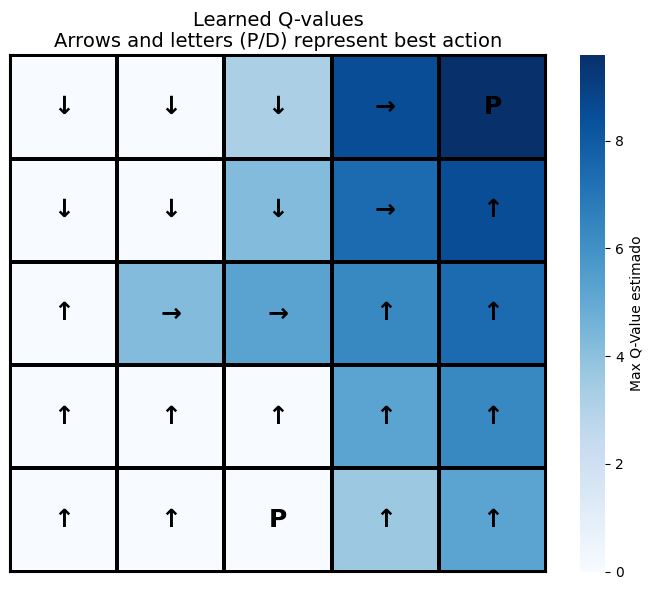

In [21]:
env.reset(seed=SEED)
plot_taxi_q_values_map(agent_03_decay.get_q_values(), env)

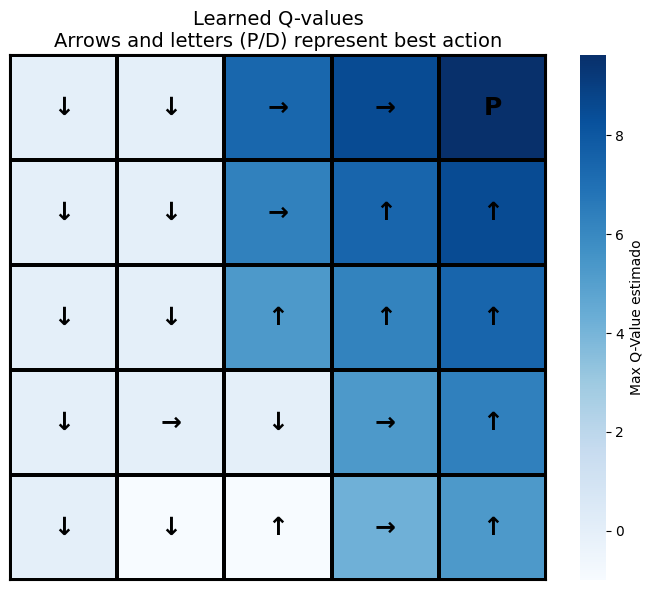

In [22]:
env.reset(seed=SEED)
plot_taxi_q_values_map(agent_03_nodecay.get_q_values(), env)

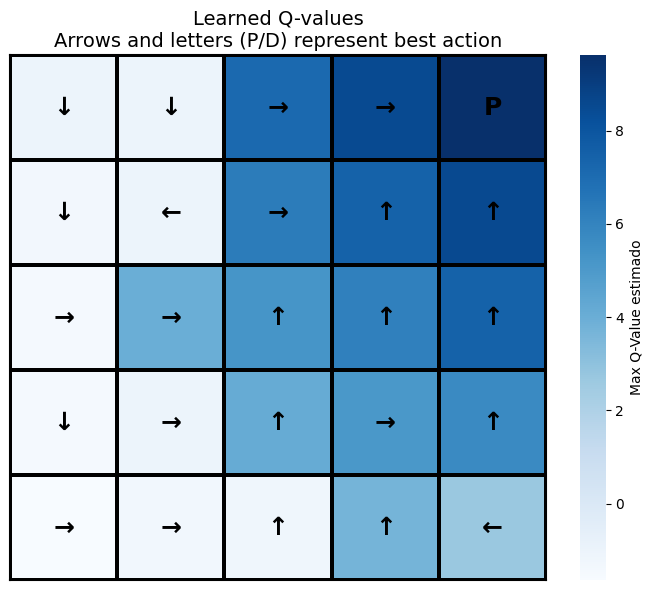

In [23]:
env.reset(seed=SEED)
plot_taxi_q_values_map(agent_07_decay.get_q_values(), env)

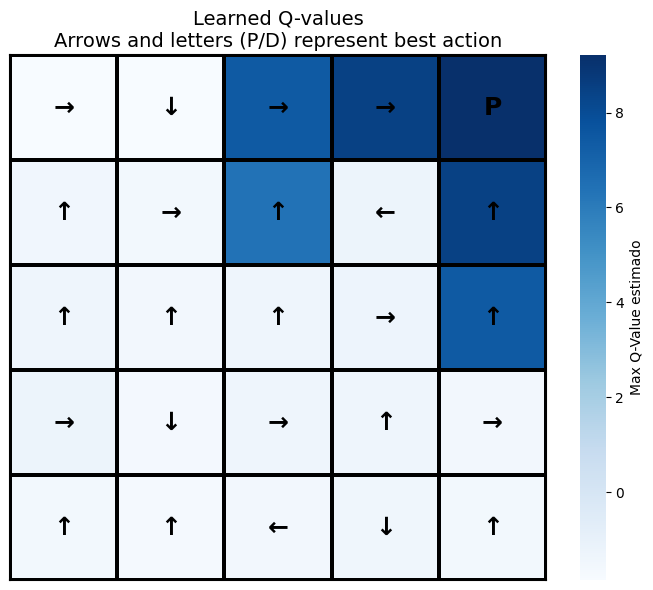

In [24]:
env.reset(seed=SEED)
plot_taxi_q_values_map(agent_07_nodecay.get_q_values(), env)

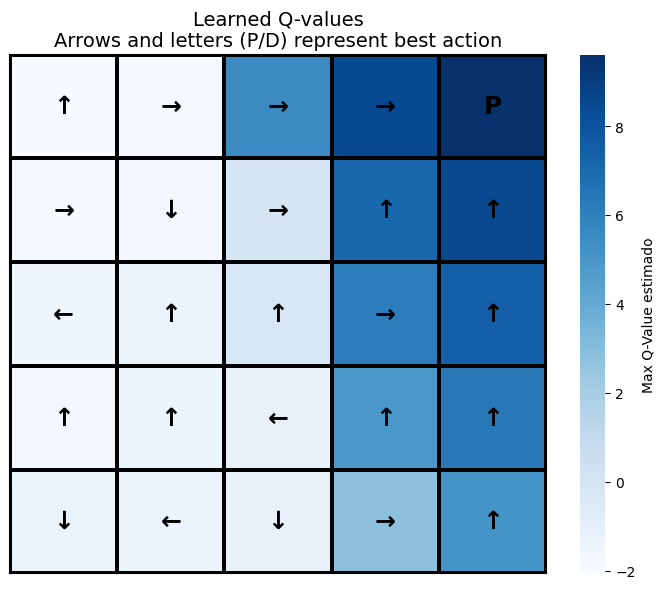

In [25]:
env.reset(seed=SEED)
plot_taxi_q_values_map(agent_1_decay.get_q_values(), env)

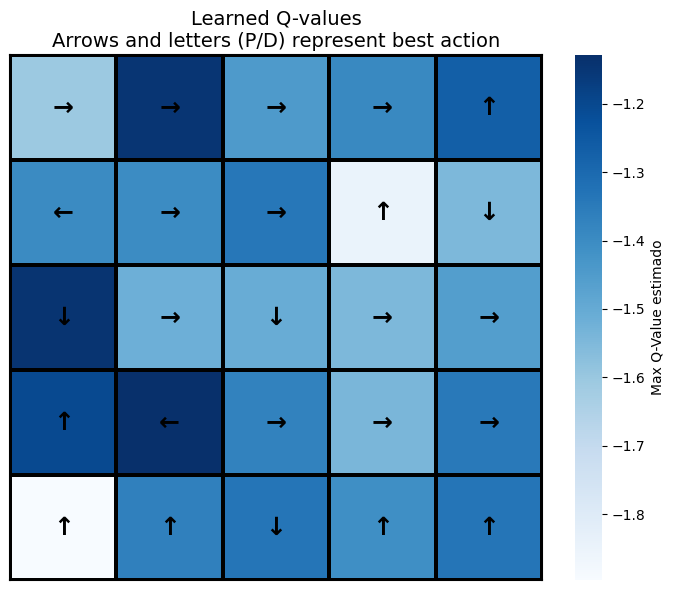

In [26]:
env.reset(seed=SEED)
plot_taxi_q_values_map(agent_1_nodecay.get_q_values(), env)

Vemos cómo lo que vemos con estas tablas va en la misma línea de lo visto en las gráficas de rewards. Vemos cómo el agente claramente ha aprendido cómo ir a recoger al cliente en los agentes con $\epsilon$ = 0.3. Ocurre lo mismo con $\epsilon$ = 0.7 con decay, aunque en el caso sin decay se ve claramente que el agente no ha aprendido tanto. Con $\epsilon$ = 1 es interesante observar que cuando tenemos decay, el agente consigue "converger" hacia unos valores de Q que permiten recoger correctamente al cliente, de mejor forma incluso que con $\epsilon$ = 0.7 sin decay (en la gráfica de recompensas ya vimos que terminaba por encima). Sin embargo, sin decay el comportamiento es bastante aleatorio, lo que confirma que con tanta exploración el agente no consigue aprender.

Debido a todo esto, vamos a generar un gif con el comportameinto de la política obtenida en el mejor caso, epsilon 0.3 con decay.

Guardado en: MCP_Tv3.gif



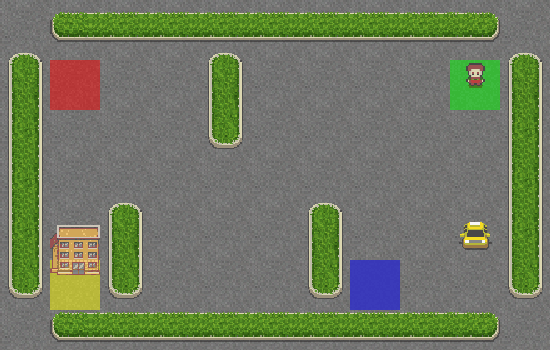

In [ ]:
# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
reward, len_episode, frames = capture_optimal_behavior(agent_03_decay)

# Crear el GIF a partir de los fotogramas capturados.
path = create_gif_from_frames(frames, "MCP_Tv3.gif")
print("Guardado en:", path)

show_gif_in_notebook(path)

Vemos cómo el taxi consigue recoger al cliente y llevarlo a su destino.

Ahora vamos a dejar el epsilon fijo, dejándolo en 0.7 debido a que, aunque no fue el agente que mejor resultado obtuvo, no se quedó demasiado lejos y es un valor que asegura suficiente exploración para estudiar adecuadamente el impacto del factor de descuento. Además, dejaremos el decay activado. Vamos entonces a variar el otro parámetro, el gamma (factor de descuento).

El objetivo de este experimento es estudiar cómo afecta la consideración de recompensas futuras al proceso de aprendizaje. Recordemos que este parámetro controla el peso relativo entre recompensas inmediatas y recompensas a largo plazo:

- Valores bajos de gamma favorecen estrategias más miopes, priorizando recompensas cercanas.
- Valores altos de gamma fomentan políticas más planificadas, al dar mayor importancia a recompensas futuras.

Este análisis permite comprender hasta qué punto el rendimiento del agente depende del horizonte temporal considerado durante la actualización de los valores Q.

Definimos los agentes con gamma 0.9 y 0.95 (el de 0.99 ya lo teníamos antes) y ejecutamos los entrenamientos.

In [27]:
agent_07_decay3 = MonteCarloOffPolicyAgent(env, epsilon=0.7, use_decay=True, gamma=0.9)
agent_07_decay4 = MonteCarloOffPolicyAgent(env, epsilon=0.7, use_decay=True, gamma=0.95)


In [28]:
list_len8, list_stats8 = on_policy_all_visit(agent_07_decay3, n_episodes)

 10%|█         | 1010/10000 [00:14<02:59, 50.09it/s]

success: -631.291, epsilon: 0.7


 20%|██        | 2048/10000 [00:24<00:30, 259.19it/s]

success: -530.5835, epsilon: 0.49975012493753124


 31%|███       | 3107/10000 [00:27<00:14, 476.70it/s]

...

 81%|████████  | 8095/10000 [00:36<00:02, 635.10it/s]

success: -147.408125, epsilon: 0.1249843769528809


 91%|█████████ | 9054/10000 [00:37<00:01, 512.05it/s]

success: -131.66933333333333, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [00:40<00:00, 249.44it/s]


In [29]:
list_len9, list_stats9 = on_policy_all_visit(agent_07_decay4, n_episodes)

 10%|█         | 1025/10000 [00:13<01:15, 119.38it/s]

success: -603.542, epsilon: 0.7


 21%|██        | 2055/10000 [00:20<00:31, 248.94it/s]

success: -440.454, epsilon: 0.49975012493753124


 31%|███       | 3084/10000 [00:23<00:11, 580.71it/s]

...

 81%|████████▏ | 8132/10000 [00:30<00:02, 738.24it/s]

success: -117.875625, epsilon: 0.1249843769528809


 91%|█████████ | 9091/10000 [00:31<00:01, 767.28it/s]

success: -104.62877777777778, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [00:32<00:00, 307.18it/s]


Vamos a ver los resultados.

In [30]:
dict_stats3 = {'gamma=0.9': list_stats8, 'gamma=0.95': list_stats9, 'gamma=0.99': list_stats}
dict_len3 = {'gamma=0.9': list_len8, 'gamma=0.95': list_len9, 'gamma=0.99': list_len}

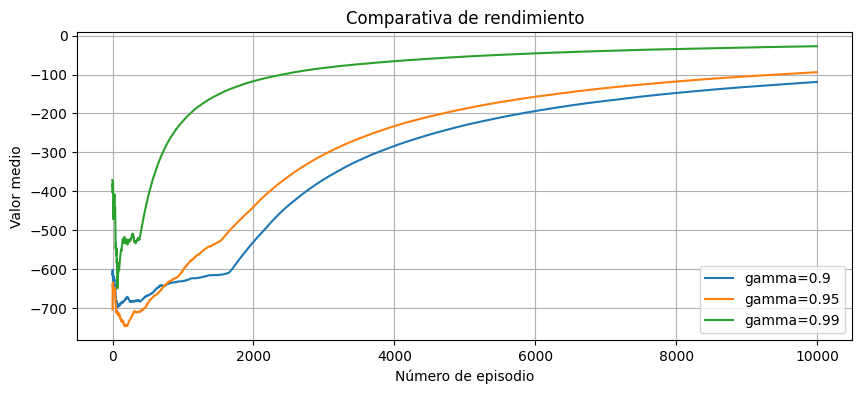

In [31]:
draw_multiple_learning_curves(dict_stats3)

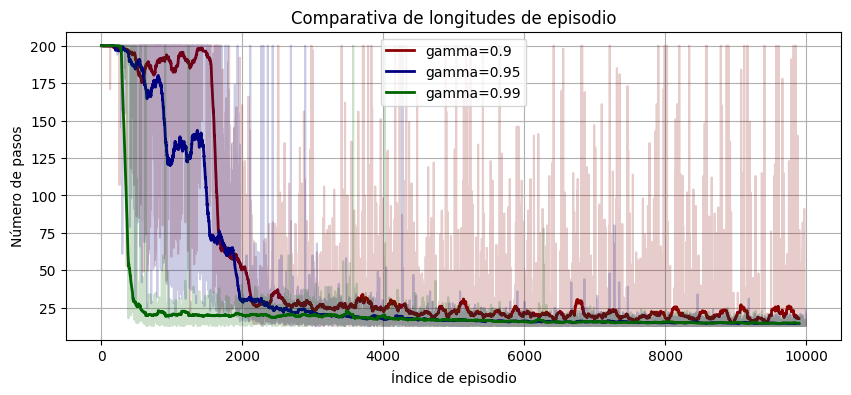

In [32]:
draw_episode_length_comparison(dict_len3)

Observamos que la longitud de los episodios disminuye muy rápidamente, estando siempre muy baja. Pero lo más interesante se observa en la comparativa de rendimiento. Vemos cómo conforme disminuye el valor de gamma el rendimiento también disminuye. Estos resultados muestran claramente la importancia del factor de descuento en la valoración de recompensas futuras. Con valores altos de gamma, el agente considera de manera más significativa las recompensas lejanas, lo que le permite planificar trayectorias completas hacia el objetivo y alcanzar un rendimiento superior. Por el contrario, con gamma más bajos, el agente se centra en recompensas inmediatas y tiende a tomar decisiones miope, lo que explica la disminución del rendimiento observado. Esto es especialmente importante en entornos más complejos como el que estamos usando, Taxi-v3.

## Entorno Frozen Lake 4x4

Tras analizar los resultados obtenidos en el entorno Taxi-v3, se observa que, aunque el agente logra cierta mejora progresiva, el rendimiento final no resulta especialmente satisfactorio. Esto es coherente con la complejidad del entorno, que presenta un espacio de estados relativamente grande, múltiples penalizaciones intermedias y una estructura de recompensas que exige secuencias largas y coherentes de acciones para alcanzar el objetivo. En este contexto, los métodos Monte Carlo pueden verse especialmente afectados por la alta varianza de los retornos y la necesidad de completar episodios enteros antes de actualizar la función de valor. En este sentido, métodos basados en *Diferencias Temporales*, como SARSA o Q-Learning, suelen mostrar mejores resultados en este tipo de entornos, ya que actualizan los valores de forma incremental en cada paso, reduciendo la varianza de las estimaciones y propagando la información de recompensa de manera más eficiente a lo largo del episodio.

Por este motivo, resulta razonable contrastar el comportamiento del agente en un entorno más sencillo como Frozen Lake 4x4 no resbaladizo. Este entorno presenta un espacio de estados mucho más reducido y una dinámica más simple, lo que permite analizar con mayor claridad la capacidad del algoritmo para aprender una política adecuada sin que la complejidad estructural del problema enmascare los resultados. Además, al tratarse de un escenario clásico en aprendizaje por refuerzo, facilita la comparación cualitativa del proceso de convergencia y la interpretación de las políticas aprendidas.

Creamos el entorno y el agente, y ejecutamos el aprendizaje.

In [ ]:
env2 = gym.make('FrozenLake-v1', is_slippery=False, map_name="4x4", render_mode="rgb_array", max_episode_steps=100)

agent_03_decay2 = MonteCarloOffPolicyAgent(env2, epsilon=0.3, use_decay=True, gamma=0.99)
agent_03_nodecay2 = MonteCarloOffPolicyAgent(env2, epsilon=0.3, use_decay=False, gamma=0.99)
agent_07_decay2 = MonteCarloOffPolicyAgent(env2, epsilon=0.7, use_decay=True, gamma=0.99)
agent_07_nodecay2 = MonteCarloOffPolicyAgent(env2, epsilon=0.7, use_decay=False, gamma=0.99)
agent_1_decay2 = MonteCarloOffPolicyAgent(env2, epsilon=1.0, use_decay=True, gamma=0.99)
agent_1_nodecay2 = MonteCarloOffPolicyAgent(env2, epsilon=1.0, use_decay=False, gamma=0.99)

Vamos a ver los resultados.

In [ ]:
n_episodes = 50000

list_len10, list_stats10 = on_policy_all_visit(agent_03_decay2, n_episodes)

 10%|█         | 5043/50000 [00:11<02:19, 322.69it/s]

success: 0.0, epsilon: 0.19996000799840033


 20%|██        | 10040/50000 [00:30<02:54, 228.41it/s]

success: 0.0, epsilon: 0.0999900009999


 30%|███       | 15031/50000 [00:55<03:00, 193.37it/s]

...

 80%|████████  | 40023/50000 [03:30<01:08, 145.63it/s]

success: 0.0, epsilon: 0.02499937501562461


 90%|█████████ | 45019/50000 [04:04<00:32, 155.49it/s]

success: 0.0, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [04:37<00:00, 180.16it/s]


In [ ]:
list_len11, list_stats11 = on_policy_all_visit(agent_03_nodecay2, n_episodes)

 11%|█         | 5291/50000 [00:08<00:28, 1560.97it/s]

success: 0.0804, epsilon: 0.3


 20%|██        | 10239/50000 [00:11<00:22, 1794.12it/s]

success: 0.3297, epsilon: 0.3


 30%|███       | 15113/50000 [00:14<00:27, 1248.55it/s]

...

 81%|████████  | 40277/50000 [00:29<00:05, 1742.41it/s]

success: 0.5479, epsilon: 0.3


 91%|█████████ | 45304/50000 [00:32<00:02, 1880.81it/s]

success: 0.5578444444444445, epsilon: 0.3


100%|██████████| 50000/50000 [00:34<00:00, 1434.33it/s]


In [ ]:
list_len12, list_stats12 = on_policy_all_visit(agent_07_decay2, n_episodes)

 10%|█         | 5207/50000 [00:02<00:22, 2001.58it/s]

success: 0.444, epsilon: 0.19996000799840033


 20%|██        | 10120/50000 [00:05<00:32, 1213.24it/s]

success: 0.6446, epsilon: 0.0999900009999


 31%|███       | 15265/50000 [00:08<00:17, 1977.77it/s]

...

 81%|████████  | 40290/50000 [00:22<00:04, 1978.91it/s]

success: 0.87685, epsilon: 0.02499937501562461


 91%|█████████ | 45331/50000 [00:25<00:02, 1924.50it/s]

success: 0.8879111111111111, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:27<00:00, 1806.37it/s]


In [ ]:
list_len13, list_stats13 = on_policy_all_visit(agent_07_nodecay2, n_episodes)

 10%|█         | 5153/50000 [00:03<00:33, 1348.69it/s]

success: 0.1924, epsilon: 0.7


 21%|██        | 10274/50000 [00:06<00:21, 1837.76it/s]

success: 0.1887, epsilon: 0.7


 31%|███       | 15287/50000 [00:09<00:16, 2043.83it/s]

...

 81%|████████  | 40422/50000 [00:22<00:04, 2061.28it/s]

success: 0.187725, epsilon: 0.7


 91%|█████████ | 45309/50000 [00:24<00:02, 2093.50it/s]

success: 0.18655555555555556, epsilon: 0.7


100%|██████████| 50000/50000 [00:27<00:00, 1833.57it/s]


In [ ]:
list_len14, list_stats14 = on_policy_all_visit(agent_1_decay2, n_episodes)

 10%|█         | 5241/50000 [00:03<00:24, 1795.30it/s]

success: 0.4236, epsilon: 0.19996000799840033


 21%|██        | 10259/50000 [00:06<00:20, 1942.82it/s]

success: 0.6347, epsilon: 0.0999900009999


 30%|███       | 15234/50000 [00:09<00:18, 1930.92it/s]

...

 80%|████████  | 40227/50000 [00:23<00:05, 1952.97it/s]

success: 0.87345, epsilon: 0.02499937501562461


 91%|█████████ | 45261/50000 [00:25<00:02, 2040.23it/s]

success: 0.8849555555555556, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:29<00:00, 1723.31it/s]


In [ ]:
list_len15, list_stats15 = on_policy_all_visit(agent_1_nodecay2, n_episodes)

 10%|█         | 5249/50000 [00:02<00:23, 1929.16it/s]

success: 0.016, epsilon: 1.0


 21%|██        | 10295/50000 [00:05<00:20, 1950.85it/s]

success: 0.0169, epsilon: 1.0


 31%|███       | 15287/50000 [00:08<00:17, 2020.88it/s]

...

 81%|████████  | 40277/50000 [00:21<00:05, 1835.75it/s]

success: 0.015275, epsilon: 1.0


 91%|█████████ | 45273/50000 [00:25<00:02, 1664.03it/s]

success: 0.014955555555555555, epsilon: 1.0


100%|██████████| 50000/50000 [00:28<00:00, 1780.17it/s]


Ahora mostramos los resultados.

In [ ]:
dict_stats2 = {'eps=0.3, decay=True': list_stats10, 'eps=0.3, decay=False': list_stats11, 'eps=0.7, decay=True': list_stats12, 'eps=0.7, decay=False': list_stats13, 'eps=1.0, decay=True': list_stats14, 'eps=1.0, decay=False': list_stats15}
dict_len2 = {'eps=0.3, decay=True': list_len10, 'eps=0.3, decay=False': list_len11, 'eps=0.7, decay=True': list_len12, 'eps=0.7, decay=False': list_len13, 'eps=1.0, decay=True': list_len14, 'eps=1.0, decay=False': list_len15}

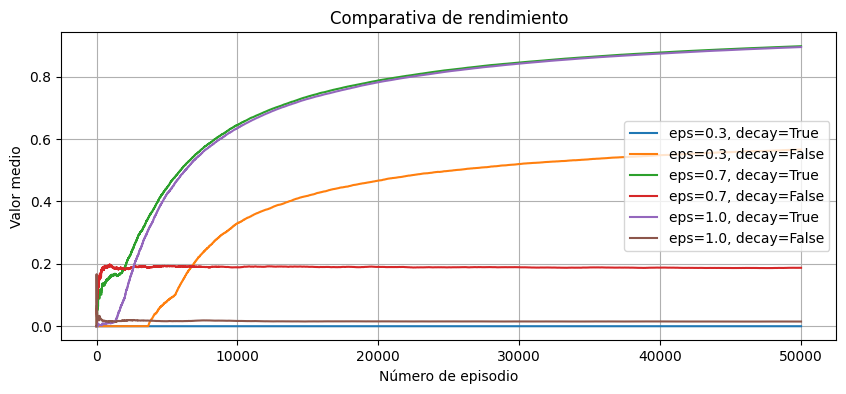

In [ ]:
draw_multiple_learning_curves(dict_stats2)

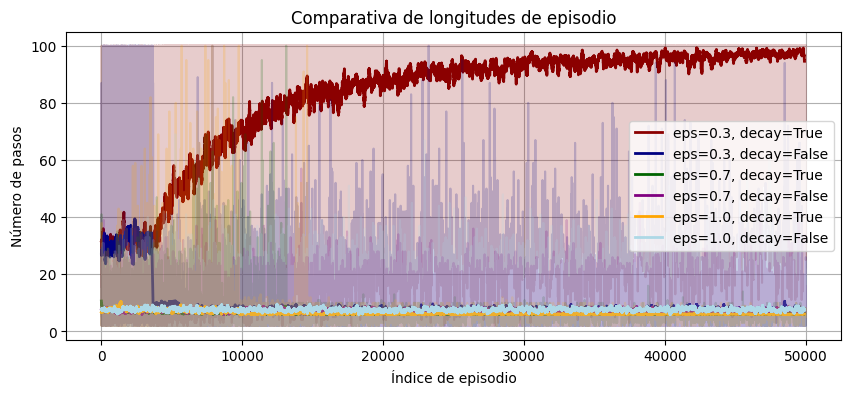

In [ ]:
draw_episode_length_comparison(dict_len2)

Vemos cómo, en comparación con los resultados que se mostraban para Taxi-v3, estos son mucho mejores en el contexto del entorno correspondiente. Se observa que las configuraciones con decay son las que mejor resultado obtienen, siendo cuanto mayor el epsilon mejor (más exploración inicial que permite observar bien pero el decay hace que se pueda obtener buen resultado). Las configuraciones con epsilon 0.3 con decay y epsilon 1.0 sin decay obtienen los peores resultados, seguramente debido a demasiado poca exploración en una y en demasiada exploración en la otra

## Posibles mejoras y líneas de Investigación Futuras

**Variaciones en el decaimiento de epsilon:** Se ha utilizado un esquema inversamente proporcional para el decaimiento de epsilon, pero se podría estudiar la influencia de otros métodos de decaimiento. Se ha observado que en algunos casos el decaimiento provocaba que la exploración no fuera suficiente y el rendimiento del agente no llegase a ser bueno. Probar con otros esquemas de decaimiento sería interesante.

**Análisis más profundo del factor de descuento gamma:** En este trabajo se han probado distintos valores de gamma para un epsilon seleccionado, pero se podrían explorar combinaciones adicionales para entender mejor la interacción entre la planificación a largo plazo y la exploración inicial.

**Aumento del número de episodios y análisis estadístico:** Aunque 10000 episodios para Taxi-v3 y 50000 para Frozen Lake permiten observar tendencias claras, ampliar el número de episodios podría ayudar a verificar la convergencia real de las políticas. Además, repetir cada configuración varias veces con distintas semillas aleatorias permitiría realizar un análisis estadístico más riguroso (media y desviación estándar del rendimiento), reduciendo el impacto de la estocasticidad del entorno.

**Exploración de estrategias alternativas de exploración:** Más allá de la política $\epsilon$-greedy, podrían evaluarse enfoques como softmax o métodos basados en incertidumbre. Estas estrategias podrían proporcionar un equilibrio exploración–explotación más eficiente, especialmente en fases tempranas del entrenamiento donde la información disponible es limitada.
